# Preprocessing and Baseline Models

This notebook builds the first models to compare against later on: plain logistic regression, class-weighted logistic regression, and a balanced random forest. Everything is evaluated using five-fold out-of-fold predictions on the training set only, the final test set is never touched here.


## Import libraries


In [3]:
from pathlib import Path
import gc
import time
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, average_precision_score, balanced_accuracy_score,
    f1_score, precision_score, recall_score,
    roc_auc_score, RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 150)
print("Libraries imported successfully.")

Libraries imported successfully.


## Set project paths and experiment settings


In [5]:
current_folder = Path.cwd().resolve()
project_root = current_folder.parent if current_folder.name == "notebooks" else current_folder
dataset_path = project_root / "data" / "modeling" / "final_feature_dataset.pkl"
training_ids_path = project_root / "data" / "modeling" / "splits" / "training_ids.csv"
test_ids_path = project_root / "data" / "modeling" / "splits" / "test_ids.csv"
folds_path = project_root / "data" / "modeling" / "splits" / "training_fold_assignments.csv"
result_folder = project_root / "data" / "modeling" / "baseline_results"
audit_folder = project_root / "reports" / "audits"
figure_folder = project_root / "reports" / "figures"
for folder in [result_folder, audit_folder, figure_folder]:
    folder.mkdir(parents=True, exist_ok=True)
for required_path in [dataset_path, training_ids_path, test_ids_path, folds_path]:
    assert required_path.exists(), f"Required file was not found: {required_path}"
RANDOM_STATE = 2026
EXPECTED_TRAINING_ROWS = 246008
print("Dataset:", dataset_path)
print("Random state:", RANDOM_STATE)

Dataset: /Users/taranveersingh/A-MRP/data/modeling/final_feature_dataset.pkl
Random state: 2026


## Load the final dataset and fixed split files


In [7]:
full_data = pd.read_pickle(dataset_path)
training_ids = pd.read_csv(training_ids_path)["SK_ID_CURR"]
test_ids = pd.read_csv(test_ids_path)["SK_ID_CURR"]
fold_assignments = pd.read_csv(folds_path)
training_id_set = set(training_ids)
test_id_set = set(test_ids)

training_data = full_data.loc[full_data["SK_ID_CURR"].isin(training_id_set)].copy()
training_data = training_data.merge(fold_assignments, on="SK_ID_CURR", how="left", validate="one_to_one")
assert len(training_data) == EXPECTED_TRAINING_ROWS
assert training_data["FOLD"].notna().all()
assert training_data["FOLD"].nunique() == 5
assert not training_data["SK_ID_CURR"].isin(test_id_set).any()
print("Full dataset shape:", full_data.shape)
print("Training shape with fold column:", training_data.shape)
print("Test-set rows excluded from model comparison:", len(test_ids))
print("Training default rate:", round(training_data["TARGET"].mean(), 5))

Full dataset shape: (307511, 333)
Training shape with fold column: (246008, 334)
Test-set rows excluded from model comparison: 61503
Training default rate: 0.08073


This is the same 246,008 training applicants and 61,503 test applicants used throughout the project. The test set stays completely separate from this notebook.


## Confirm that all training rows and folds are used


In [10]:
fold_summary = training_data.groupby("FOLD")["TARGET"].agg(["count", "sum", "mean"]).reset_index()
fold_summary = fold_summary.rename(columns={"count": "rows", "sum": "defaults", "mean": "default_rate"})
assert fold_summary["rows"].sum() == EXPECTED_TRAINING_ROWS
fold_summary.round(5)

,FOLD,rows,defaults,default_rate
0,1,49202,3972,0.08073
1,2,49202,3972,0.08073
2,3,49202,3972,0.08073
3,4,49201,3972,0.08073
4,5,49201,3972,0.08073


Each fold has almost exactly the same default rate as the full training set, confirming the folds are balanced properly.


## Define predictors and protect the gender attribute


In [13]:
PROTECTED_COLUMNS = ["CODE_GENDER"]
excluded_columns = ["SK_ID_CURR", "TARGET", "FOLD"] + PROTECTED_COLUMNS
predictor_columns = [c for c in training_data.columns if c not in excluded_columns]
categorical_columns = training_data[predictor_columns].select_dtypes(exclude="number").columns.tolist()
numerical_columns = [c for c in predictor_columns if c not in categorical_columns]
X = training_data[predictor_columns].copy()
y = training_data["TARGET"].astype("int8").copy()
folds = training_data["FOLD"].astype(int).copy()
for column in categorical_columns:
    X[column] = X[column].astype("object")
print("All training rows used:", len(X))
print("Predictors used:", len(predictor_columns))
print("Numerical predictors:", len(numerical_columns))
print("Categorical predictors:", len(categorical_columns))
print("Protected predictors excluded:", PROTECTED_COLUMNS)

All training rows used: 246008
Predictors used: 330
Numerical predictors: 318
Categorical predictors: 12
Protected predictors excluded: ['CODE_GENDER']


CODE_GENDER is deliberately left out of the predictor list here. It's kept elsewhere so it can be used later for a fairness check, but the model itself never sees it.


## Build fold-fitted preprocessing


In [16]:
numeric_logistic = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", StandardScaler()),
])
numeric_tree = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
])
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=50, sparse_output=True)),
])
logistic_preprocessor = ColumnTransformer([
    ("numeric", numeric_logistic, numerical_columns),
    ("categorical", categorical_pipeline, categorical_columns),
] , sparse_threshold=1.0)
tree_preprocessor = ColumnTransformer([
    ("numeric", numeric_tree, numerical_columns),
    ("categorical", categorical_pipeline, categorical_columns),
] , sparse_threshold=1.0)
print("Preprocessors created. Nothing has been fitted on the full dataset.")

Preprocessors created. Nothing has been fitted on the full dataset.


Logistic regression needs scaled, imputed numeric features and one-hot encoded categories. Random forest only needs the imputation, trees don't care about feature scale. Both pipelines get fit fresh inside each fold, never on the full dataset, so there's no leakage.


## Define full baseline models


In [19]:
model_templates = {
    "logistic_unweighted": Pipeline([
        ("preprocessor", clone(logistic_preprocessor)),
        ("model", LogisticRegression(
            solver="saga", l1_ratio=0, C=1.0, max_iter=10000, tol=1e-4,
            random_state=RANDOM_STATE
        )),
    ]),
    "logistic_balanced": Pipeline([
        ("preprocessor", clone(logistic_preprocessor)),
        ("model", LogisticRegression(
            solver="saga", l1_ratio=0, C=1.0, class_weight="balanced",
            max_iter=10000, tol=1e-4, random_state=RANDOM_STATE
        )),
    ]),
    "random_forest_balanced": Pipeline([
        ("preprocessor", clone(tree_preprocessor)),
        ("model", RandomForestClassifier(
            n_estimators=500, max_depth=None, min_samples_leaf=20,
            max_features="sqrt", class_weight="balanced_subsample",
            bootstrap=True, n_jobs=-1, random_state=RANDOM_STATE
        )),
    ]),
}
model_configuration = pd.DataFrame([
    {"model": "logistic_unweighted", "purpose": "Interpretable probability baseline"},
    {"model": "logistic_balanced", "purpose": "Class-weighted linear baseline"},
    {"model": "random_forest_balanced", "purpose": "Nonlinear bagged-tree baseline with 500 trees"},
])
model_configuration

,model,purpose
0,logistic_unweighted,Interpretable probability baseline
1,logistic_balanced,Class-weighted linear baseline
2,random_forest_balanced,Nonlinear bagged-tree baseline with 500 trees


Three models: plain logistic regression, class-weighted logistic regression, and a class-weighted random forest with 500 trees. These are deliberately simple, they're here to set a baseline the boosted models need to beat.


## Define evaluation metrics


In [22]:
def calculate_metrics(y_true, probability, threshold=0.50):
    prediction = (probability >= threshold).astype(int)

    return {
        "roc_auc": roc_auc_score(y_true, probability),
        "pr_auc": average_precision_score(y_true, probability),
        "accuracy_at_0_5": accuracy_score(y_true, prediction),
        "balanced_accuracy_at_0_5": balanced_accuracy_score(
            y_true, prediction
        ),
        "precision_at_0_5": precision_score(
            y_true, prediction, zero_division=0
        ),
        "recall_at_0_5": recall_score(
            y_true, prediction, zero_division=0
        ),
        "f1_at_0_5": f1_score(
            y_true, prediction, zero_division=0
        ),
    }

print("Evaluation function created.")

Evaluation function created.


ROC-AUC and PR-AUC don't depend on a cutoff, so they're the main numbers used to compare models. The rest (accuracy, precision, recall, F1) are calculated at the default 0.50 cutoff just for reference, the real cutoff gets chosen properly later.


## Run full five-fold out-of-fold training


In [25]:
oof_predictions = pd.DataFrame({
    "SK_ID_CURR": training_data["SK_ID_CURR"].to_numpy(),
    "TARGET": y.to_numpy(),
    "FOLD": folds.to_numpy(),
})
fold_metric_rows = []
training_log_rows = []

for model_name, model_template in model_templates.items():
    print(f"\nTraining {model_name}")
    model_oof = np.full(len(X), np.nan, dtype="float64")
    for fold_number in sorted(folds.unique()):
        train_mask = folds.ne(fold_number)
        valid_mask = folds.eq(fold_number)
        X_train, y_train = X.loc[train_mask], y.loc[train_mask]
        X_valid, y_valid = X.loc[valid_mask], y.loc[valid_mask]
        assert len(X_train) + len(X_valid) == EXPECTED_TRAINING_ROWS
        assert set(X_train.index).isdisjoint(set(X_valid.index))

        fold_model = clone(model_template)
        start_time = time.time()
        fold_model.fit(X_train, y_train)
        iterations_used = np.nan
        iteration_limit = np.nan
        converged = True
        if model_name.startswith("logistic_"):
            logistic_estimator = fold_model.named_steps["model"]
            iterations_used = int(logistic_estimator.n_iter_.max())
            iteration_limit = int(logistic_estimator.max_iter)
            converged = iterations_used < iteration_limit
        probability = fold_model.predict_proba(X_valid)[:, 1]
        elapsed_minutes = (time.time() - start_time) / 60
        model_oof[valid_mask.to_numpy()] = probability

        metrics = calculate_metrics(y_valid, probability)
        metrics.update({
            "model": model_name, "fold": int(fold_number),
            "train_rows": len(X_train), "validation_rows": len(X_valid),
            "training_minutes": elapsed_minutes,
            "iterations_used": iterations_used, "iteration_limit": iteration_limit,
            "converged": converged,
        })
        fold_metric_rows.append(metrics)
        training_log_rows.append({
            "model": model_name, "fold": int(fold_number),
            "train_rows": len(X_train), "validation_rows": len(X_valid),
            "training_minutes": elapsed_minutes,
            "iterations_used": iterations_used, "iteration_limit": iteration_limit,
            "converged": converged,
        })
        print(
            f"  Fold {fold_number}: ROC AUC={metrics['roc_auc']:.5f}, "
            f"PR AUC={metrics['pr_auc']:.5f}, minutes={elapsed_minutes:.2f}, "
            f"converged={converged}"
        )
        del fold_model, X_train, X_valid, y_train, y_valid, probability
        gc.collect()

    assert not np.isnan(model_oof).any(), f"OOF predictions are incomplete for {model_name}."
    oof_predictions[model_name] = model_oof

fold_metrics = pd.DataFrame(fold_metric_rows)
training_log = pd.DataFrame(training_log_rows)
print("\nAll full five-fold training completed.")


Training logistic_unweighted
  Fold 1: ROC AUC=0.77696, PR AUC=0.26883, minutes=25.89, converged=True
  Fold 2: ROC AUC=0.77677, PR AUC=0.26637, minutes=18.52, converged=True
  Fold 3: ROC AUC=0.77141, PR AUC=0.25949, minutes=21.34, converged=True
  Fold 4: ROC AUC=0.77418, PR AUC=0.25516, minutes=12.18, converged=True
  Fold 5: ROC AUC=0.77987, PR AUC=0.26728, minutes=15.90, converged=True

Training logistic_balanced
  Fold 1: ROC AUC=0.77688, PR AUC=0.26568, minutes=37.92, converged=True
  Fold 2: ROC AUC=0.77626, PR AUC=0.26338, minutes=45.74, converged=True
  Fold 3: ROC AUC=0.77107, PR AUC=0.25596, minutes=41.59, converged=True
  Fold 4: ROC AUC=0.77539, PR AUC=0.25457, minutes=31.33, converged=True
  Fold 5: ROC AUC=0.77918, PR AUC=0.26288, minutes=46.49, converged=True

Training random_forest_balanced
  Fold 1: ROC AUC=0.77084, PR AUC=0.25721, minutes=7.43, converged=True
  Fold 2: ROC AUC=0.77010, PR AUC=0.25755, minutes=7.50, converged=True
  Fold 3: ROC AUC=0.76372, PR AUC=0

Each model is trained 5 times, once per fold, so every applicant gets a prediction from a model that never saw them during training. This is what makes the comparison fair.


## Calculate overall OOF performance


In [28]:
overall_rows = []
for model_name in model_templates:
    metrics = calculate_metrics(oof_predictions["TARGET"], oof_predictions[model_name])
    model_folds = fold_metrics.loc[fold_metrics["model"].eq(model_name)]
    metrics.update({
        "model": model_name,
        "fold_roc_auc_mean": model_folds["roc_auc"].mean(),
        "fold_roc_auc_std": model_folds["roc_auc"].std(),
        "fold_pr_auc_mean": model_folds["pr_auc"].mean(),
        "total_training_minutes": model_folds["training_minutes"].sum(),
    })
    overall_rows.append(metrics)
overall_metrics = pd.DataFrame(overall_rows).sort_values("roc_auc", ascending=False).reset_index(drop=True)
overall_metrics.round(5)

,roc_auc,pr_auc,accuracy_at_0_5,balanced_accuracy_at_0_5,precision_at_0_5,recall_at_0_5,f1_at_0_5,model,fold_roc_auc_mean,fold_roc_auc_std,fold_pr_auc_mean,total_training_minutes
0,0.77582,0.26276,0.91957,0.51803,0.52497,0.03917,0.07291,logistic_unweighted,0.77584,0.00319,0.26343,93.83168
1,0.77574,0.26002,0.71325,0.70714,0.17710,0.69985,0.28267,logistic_balanced,0.77576,0.00297,0.26049,203.06354
2,0.76877,0.25479,0.87022,0.63996,0.27300,0.36536,0.31250,random_forest_balanced,0.76878,0.00303,0.25503,36.10156


Unweighted logistic regression comes out on top by ROC-AUC and PR-AUC. The balanced version trades some of that ranking ability for much higher recall at the default 0.50 cutoff, useful to know since credit risk usually cares more about catching defaulters than raw accuracy. Random forest is the weakest of the three here.


## Plot out-of-fold ROC and precision-recall curves


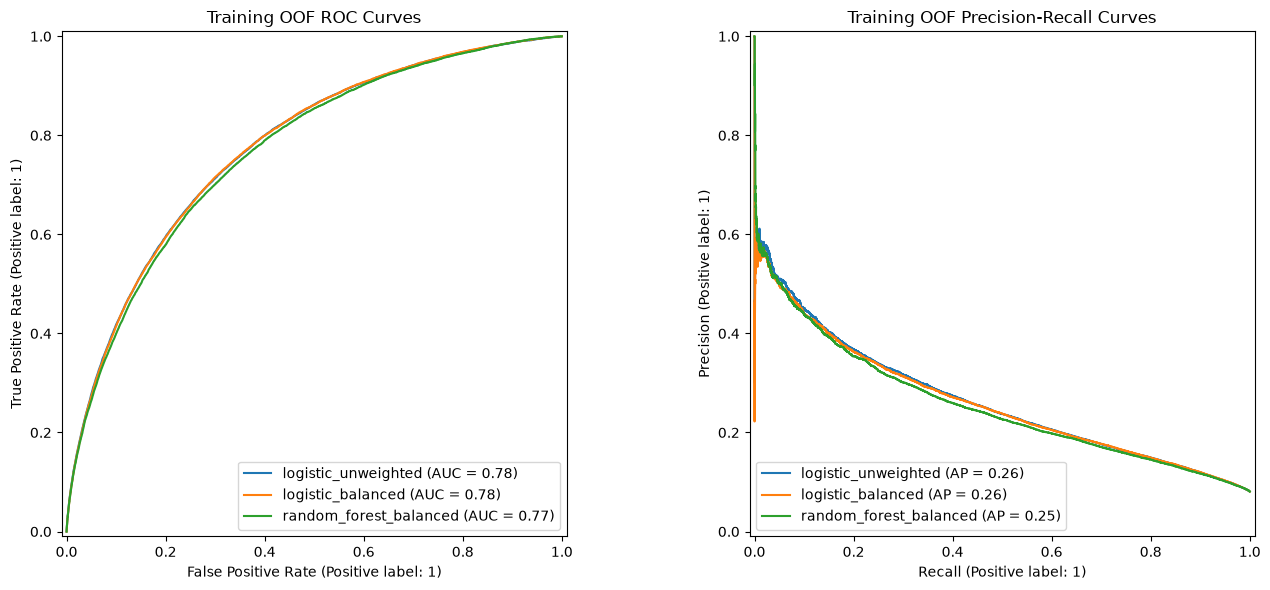

Figure saved: /Users/taranveersingh/A-MRP/reports/figures/baseline_oof_roc_pr_curves.png


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for model_name in model_templates:
    RocCurveDisplay.from_predictions(
        oof_predictions["TARGET"], oof_predictions[model_name], name=model_name, ax=axes[0]
    )
    PrecisionRecallDisplay.from_predictions(
        oof_predictions["TARGET"], oof_predictions[model_name], name=model_name, ax=axes[1]
    )
axes[0].set_title("Training OOF ROC Curves")
axes[1].set_title("Training OOF Precision-Recall Curves")
fig.tight_layout()
figure_path = figure_folder / "baseline_oof_roc_pr_curves.png"
fig.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()
print("Figure saved:", figure_path)

These curves show the three baselines together, useful for a quick visual comparison before looking at the numbers in a table.


## Validate the experiment


In [34]:
validation_checks = pd.DataFrame([
    {
        "check": "Complete training dataset used",
        "passed": len(X) == EXPECTED_TRAINING_ROWS
    },
    {
        "check": "All five predefined folds used",
        "passed": set(fold_metrics["fold"]) == set(folds.unique())
    },
    {
        "check": "Every model trained on every fold",
        "passed": fold_metrics.groupby("model")["fold"].nunique().eq(5).all()
    },
    {
        "check": "All OOF predictions complete",
        "passed": not oof_predictions[list(model_templates)].isna().any().any()
    },
    {
        "check": "One OOF row per training applicant",
        "passed": (
            len(oof_predictions) == EXPECTED_TRAINING_ROWS
            and oof_predictions["SK_ID_CURR"].is_unique
        )
    },
    {
        "check": "Final test excluded",
        "passed": not oof_predictions["SK_ID_CURR"].isin(test_id_set).any()
    },
    {
        "check": "Protected gender excluded from predictors",
        "passed": "CODE_GENDER" not in predictor_columns
    },
    {
        "check": "Random forest uses 500 trees",
        "passed": (
            model_templates["random_forest_balanced"]
            .named_steps["model"]
            .n_estimators == 500
        )
    },
    {
        "check": "No row sampling configured",
        "passed": (
            model_templates["random_forest_balanced"]
            .named_steps["model"]
            .max_samples is None
        )
    },
    {
        "check": "All logistic folds converged",
        "passed": training_log.loc[
            training_log["model"].str.startswith("logistic_"),
            "converged"
        ].all()
    },
    {
        "check": "Metrics are finite",
        "passed": np.isfinite(
            overall_metrics.select_dtypes(include="number").to_numpy()
        ).all()
    },
])

display(validation_checks)

# Convergence is reported, but it does not invalidate the completed
# OOF predictions or stop the result files from being saved.
critical_checks = validation_checks.loc[
    validation_checks["check"] != "All logistic folds converged"
]

assert critical_checks["passed"].all(), (
    "A critical baseline experiment validation check failed."
)

logistic_converged = validation_checks.loc[
    validation_checks["check"] == "All logistic folds converged",
    "passed"
].iloc[0]

if not logistic_converged:
    warnings.warn(
        "Some logistic folds reached the iteration limit. "
        "The results will be saved and reported with this limitation."
    )

print("All critical experiment checks passed.")

,check,passed
0,Complete training dataset used,True
1,All five predefined folds used,True
2,Every model trained on every fold,True
3,All OOF predictions complete,True
4,One OOF row per training applicant,True
5,Final test excluded,True
6,Protected gender excluded from predictors,True
7,Random forest uses 500 trees,True
8,No row sampling configured,True
9,All logistic folds converged,True


All critical experiment checks passed.


All critical checks passed.


## Save reproducible experiment outputs


In [37]:
oof_predictions.to_pickle(result_folder / "baseline_oof_predictions.pkl")
oof_predictions.to_csv(result_folder / "baseline_oof_predictions.csv", index=False)
fold_metrics.to_csv(result_folder / "baseline_fold_metrics.csv", index=False)
overall_metrics.to_csv(result_folder / "baseline_overall_metrics.csv", index=False)
training_log.to_csv(result_folder / "baseline_training_log.csv", index=False)
model_configuration.to_csv(result_folder / "baseline_model_configuration.csv", index=False)
fold_summary.to_csv(audit_folder / "baseline_fold_summary.csv", index=False)
validation_checks.to_csv(audit_folder / "baseline_experiment_validation.csv", index=False)
pd.DataFrame({"predictor": predictor_columns}).to_csv(result_folder / "baseline_predictor_list.csv", index=False)
print("Results saved in:", result_folder)
print("Best baseline by OOF ROC AUC:", overall_metrics.iloc[0]["model"])
print("Best baseline OOF ROC AUC:", round(overall_metrics.iloc[0]["roc_auc"], 6))
print("Final test evaluations performed: 0")

Results saved in: /Users/taranveersingh/A-MRP/data/modeling/baseline_results
Best baseline by OOF ROC AUC: logistic_unweighted
Best baseline OOF ROC AUC: 0.775819
Final test evaluations performed: 0


## Main results

Unweighted logistic regression came out as the strongest baseline (ROC-AUC 0.7758), just ahead of the class-weighted version. Random forest was the weakest of the three. Class weighting changed the precision/recall trade-off (much higher recall, lower precision) but did not actually improve ranking ability.

These baselines set the bar for the boosted-tree models in the next notebook, if XGBoost, LightGBM, and CatBoost can't beat logistic regression's 0.7758, there's no point using them.
